In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay 
from sklearn.ensemble import RandomForestClassifier

In [2]:
def wrangle(filepath):
    #read csv into DataFrame
    df = pd.read_csv(filepath)

    # =====================================================
    
    # Merge Patient Admission Date and Patient Admission Time column
    df["Admission DateTime"] = pd.to_datetime(
        df["Patient Admission Date"] + " " + df["Patient Admission Time"], dayfirst=True
    )

    # Drop columns with more than 40% null values, merged, and irrelvant 
    df.drop(columns=(["Department Referral",
                      "Patient Satisfaction Score", 
                      "Patient Admission Date",
                      "Patient Admission Time", 
                      "Patient Id", 
                      "Merged"]),
            inplace=True)

    # =====================================================
    
    # Set Admission DateTime column as index
    df.set_index("Admission DateTime", inplace=True)

    # Sort index
    df.sort_index(inplace=True)

    # Create column with day name
    df.insert(0, "Admission Day", df.index.day_name() )

    # Create Ordered Days in Visualization
    day_order = [
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ]

    df["Admission Day"] = pd.Categorical(
        df["Admission Day"],
        categories = day_order,
        ordered = True
    )


     # Create column with month name
    df.insert(0, "Admission Month", df.index.month_name() )

    # Create Ordered Days in Visualization
    month_order = [
        "January",
        "February",
        "March",
        "April",
        "May",
        "June",
        "July",
        "August",
        "September",
        "October",
        "November",
        "December"
    ]

    df["Admission Month"] = pd.Categorical(
        df["Admission Month"],
        categories = month_order,
        ordered = True
    )

    # =====================================================
    # Create Shift Duty Column
    shift_hour = df.index.hour

    shift_conditions = [
        (shift_hour >= 6) & (shift_hour < 14),   # 06:00–13:59
        (shift_hour >= 14) & (shift_hour < 21), # 14:00–20:59
        (shift_hour >= 21) | (shift_hour < 6)   # 21:00–05:59
    ]

    shift_labels = [
        "Morning",
        "Afternoon",
        "Night"
    ]

    shift_duty = np.select(
        shift_conditions,
        shift_labels,
        default="Unknown"
    )

    # Insert as FIRST column
    df.insert(0, "Shift Duty", shift_duty)

    # Make Shift Duty ordered
    df["Shift Duty"] = pd.Categorical(
        df["Shift Duty"],
        categories=["Morning", "Afternoon", "Night"],
        ordered=True
    )
    # =====================================================
    # Create Grouped Waittime
    waittime_bins = [0, 15, 30, 60, np.inf]

    waittime_labels = [
        "0–15 mins",
        "16–30 mins",
        "31–60 mins",
        "60+ mins"
    ]

    df["Grouped Waittime"] = pd.cut(
        df["Patient Waittime"],
        bins=waittime_bins,
        labels=waittime_labels,
        right=True,
        include_lowest=True
    )

    # Make Grouped Waittime ordered
    df["Grouped Waittime"] = pd.Categorical(
        df["Grouped Waittime"],
        categories=waittime_labels,
        ordered=True
    )

    # Drop original waittime column
    df.drop(columns="Patient Waittime", inplace=True)

    # =====================================================
    # Create Age Groups
    bins = [0, 5, 10, 15, 20, 30, 40, 50, 60, 70, 80]

    labels = [
        "Under Five",
        "School Age Child",
        "Early Adolescent",
        "Late Adolescent",
        "Young Adult",
        "Early Adult",
        "Midlife Adult",
        "Late Adult",
        "Young Elderly",
        "Older Elderly"
    ]

    df["Age Group"] = pd.cut(
        df["Patient Age"],
        bins=bins,
        labels=labels,
        right=False
    )

    # Make Age Group Chronological
    df["Age Group"] = pd.Categorical(
        df["Age Group"],
        categories=labels,
        ordered=True
    )

    # Higher-level category mapping
    age_category_map = {
        "Under Five": "Child",
        "School Age Child": "Child",

        "Early Adolescent": "Adolescent",
        "Late Adolescent": "Adolescent",

        "Young Adult": "Adult",
        "Early Adult": "Adult",
        "Midlife Adult": "Adult",
        "Late Adult": "Adult",

        "Young Elderly": "Elderly",
        "Older Elderly": "Elderly"
    }

    df["Age Category"] = df["Age Group"].map(age_category_map)

    # Make the Age Category ordered
    category_order = [
        "Child",
        "Adolescent",
        "Adult",
        "Elderly"
    ]
    
    df["Age Category"] = pd.Categorical(
        df["Age Category"],
        categories=category_order,
        ordered=True
    )

    # Color Mapping
    age_color_map = {
        "Child": "yellow",
        "Adolescent": "red",
        "Adult": "blue",
        "Elderly": "gray"
    }
    
    df["Age Color"] = df["Age Category"].map(age_color_map)

    return df

def coefficient_of_variation(series):
    return(series.std()/series.mean()) * 100

In [3]:
df = wrangle("../data/healthcare_analytics_patient_flow_data.csv")
df.head()

,Shift Duty,Admission Month,Admission Day,Patient Gender,Patient Age,Patient Race,Patient Admission Flag,Grouped Waittime,Age Group,Age Category,Age Color
Admission DateTime,,,,,,,,,,,
2023-04-01 01:13:00,Night,April,Saturday,Male,60,Two or More Races,Admission,31–60 mins,Young Elderly,Elderly,gray
2023-04-01 01:21:00,Night,April,Saturday,Male,18,Two or More Races,Admission,31–60 mins,Late Adolescent,Adolescent,red
2023-04-01 02:45:00,Night,April,Saturday,Male,62,Asian,Not Admission,0–15 mins,Young Elderly,Elderly,gray
2023-04-01 04:34:00,Night,April,Saturday,Male,79,White,Not Admission,16–30 mins,Older Elderly,Elderly,gray
2023-04-01 06:07:00,Morning,April,Saturday,Female,6,White,Admission,31–60 mins,School Age Child,Child,yellow


In [4]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9216 entries, 2023-04-01 01:13:00 to 2024-10-30 23:44:00
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   Shift Duty              9216 non-null   category
 1   Admission Month         9216 non-null   category
 2   Admission Day           9216 non-null   category
 3   Patient Gender          9216 non-null   str     
 4   Patient Age             9216 non-null   int64   
 5   Patient Race            9216 non-null   str     
 6   Patient Admission Flag  9216 non-null   str     
 7   Grouped Waittime        9216 non-null   category
 8   Age Group               9216 non-null   category
 9   Age Category            9216 non-null   category
 10  Age Color               9216 non-null   category
dtypes: category(7), int64(1), str(3)
memory usage: 424.7 KB


In [5]:
df["Patient Admission Flag"].value_counts(normalize=True)*100

Patient Admission Flag
Admission        50.043403
Not Admission    49.956597
Name: proportion, dtype: float64

In [6]:
"""My approach is to:
1. Check if Prediction of patient admission is possible based on 
Shift Duty, Patient Gender, Patient Race, Age Category, and Grouped Waittime.
This will indicate if the dataset has weak predictive signal or not.
2. If there is a signal, I will use Logistic Regression and Random Forest Classifier.
if there is no signal, I will not proceed with modeling and will instead focus on 
data collection and feature engineering."""

# for reindexing 
df = df.reset_index(drop=True)


shift_duty_f2t = pd.crosstab(
    df["Shift Duty"],
    df["Patient Admission Flag"],
    normalize="index"
) * 100

patient_gender_f2t = pd.crosstab(
    df["Patient Gender"],
    df["Patient Admission Flag"],
    normalize="index"
) * 100

patient_race_f2t = pd.crosstab(
    df["Patient Race"],
    df["Patient Admission Flag"],
    normalize="index"
) * 100

age_category_f2t = pd.crosstab(
    df["Age Category"],
    df["Patient Admission Flag"],
    normalize="index"
) * 100

patient_waittime_f2t = pd.crosstab(
    df["Grouped Waittime"],
    df["Patient Admission Flag"],
    normalize="index"
) * 100


print(
    f"""
Feature-to-Target Relationships

Shift Duty vs Patient Admission
{shift_duty_f2t}

Patient Gender vs Patient Admission
{patient_gender_f2t}

Patient Race vs Patient Admission
{patient_race_f2t}

Age Category vs Patient Admission
{age_category_f2t}

Grouped Waittime vs Patient Admission
{patient_waittime_f2t}
"""
)





Feature-to-Target Relationships

Shift Duty vs Patient Admission
Patient Admission Flag  Admission  Not Admission
Shift Duty                                      
Morning                 50.194049      49.805951
Afternoon               50.609756      49.390244
Night                   49.485714      50.514286

Patient Gender vs Patient Admission
Patient Admission Flag  Admission  Not Admission
Patient Gender                                  
Female                  50.089485      49.910515
Femaleemale             64.705882      35.294118
Male                    49.947135      50.052865

Patient Race vs Patient Admission
Patient Admission Flag         Admission  Not Admission
Patient Race                                           
African American               50.999487      49.000513
Asian                          51.037736      48.962264
Declined to Identify           49.320388      50.679612
Native American/Alaska Native  50.401606      49.598394
Pacific Islander               48.26

In [7]:
df["Patient Gender"].value_counts(normalize=True)*100

Patient Gender
Male           51.312934
Female         48.502604
Femaleemale     0.184462
Name: proportion, dtype: float64

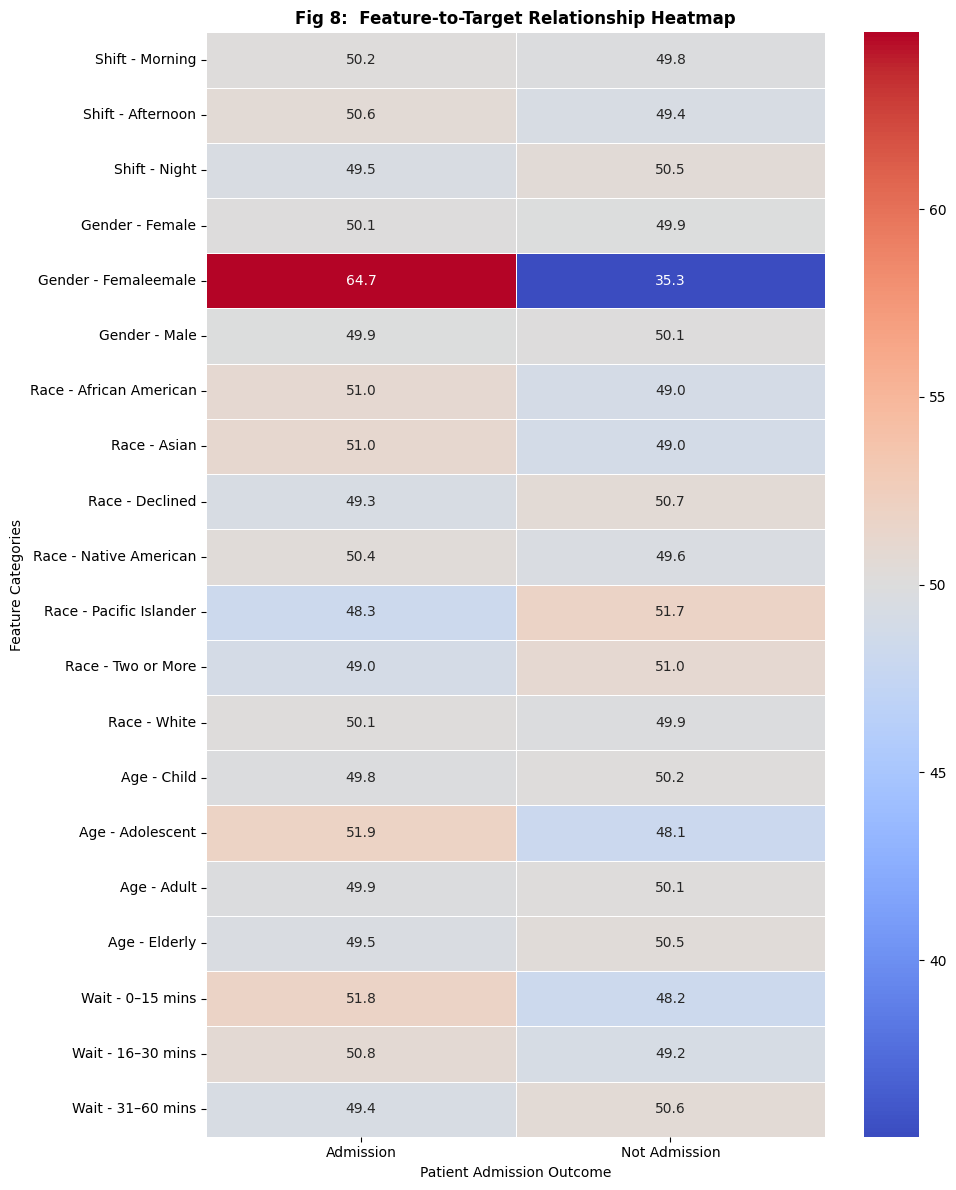

In [10]:
# Heatmap of feature-to-target relationships

# ==========================================
# Create Heatmap Data
# ==========================================

heatmap_data = pd.DataFrame({

    "Admission": [
        50.194049,
        50.609756,
        49.485714,
        50.089485,
        64.705882,
        49.947135,
        50.999487,
        51.037736,
        49.320388,
        50.401606,
        48.269581,
        49.004496,
        50.136134,
        49.810606,
        51.908397,
        49.871630,
        49.544863,
        51.756007,
        50.768654,
        49.350649
    ],

    "Not Admission": [
        49.805951,
        49.390244,
        50.514286,
        49.910515,
        35.294118,
        50.052865,
        49.000513,
        48.962264,
        50.679612,
        49.598394,
        51.730419,
        50.995504,
        49.863866,
        50.189394,
        48.091603,
        50.128370,
        50.455137,
        48.243993,
        49.231346,
        50.649351
    ]

},

index=[

    "Shift - Morning",
    "Shift - Afternoon",
    "Shift - Night",

    "Gender - Female",
    "Gender - Femaleemale",
    "Gender - Male",

    "Race - African American",
    "Race - Asian",
    "Race - Declined",
    "Race - Native American",
    "Race - Pacific Islander",
    "Race - Two or More",
    "Race - White",

    "Age - Child",
    "Age - Adolescent",
    "Age - Adult",
    "Age - Elderly",

    "Wait - 0–15 mins",
    "Wait - 16–30 mins",
    "Wait - 31–60 mins"
])

# ==========================================
# Plot Heatmap
# ==========================================

plt.figure(figsize=(10, 12))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    linewidths=0.5,
    center=50
)

plt.title("Fig 8:  Feature-to-Target Relationship Heatmap", weight="bold")

plt.xlabel("Patient Admission Outcome")
plt.ylabel("Feature Categories")

plt.tight_layout()
plt.show()

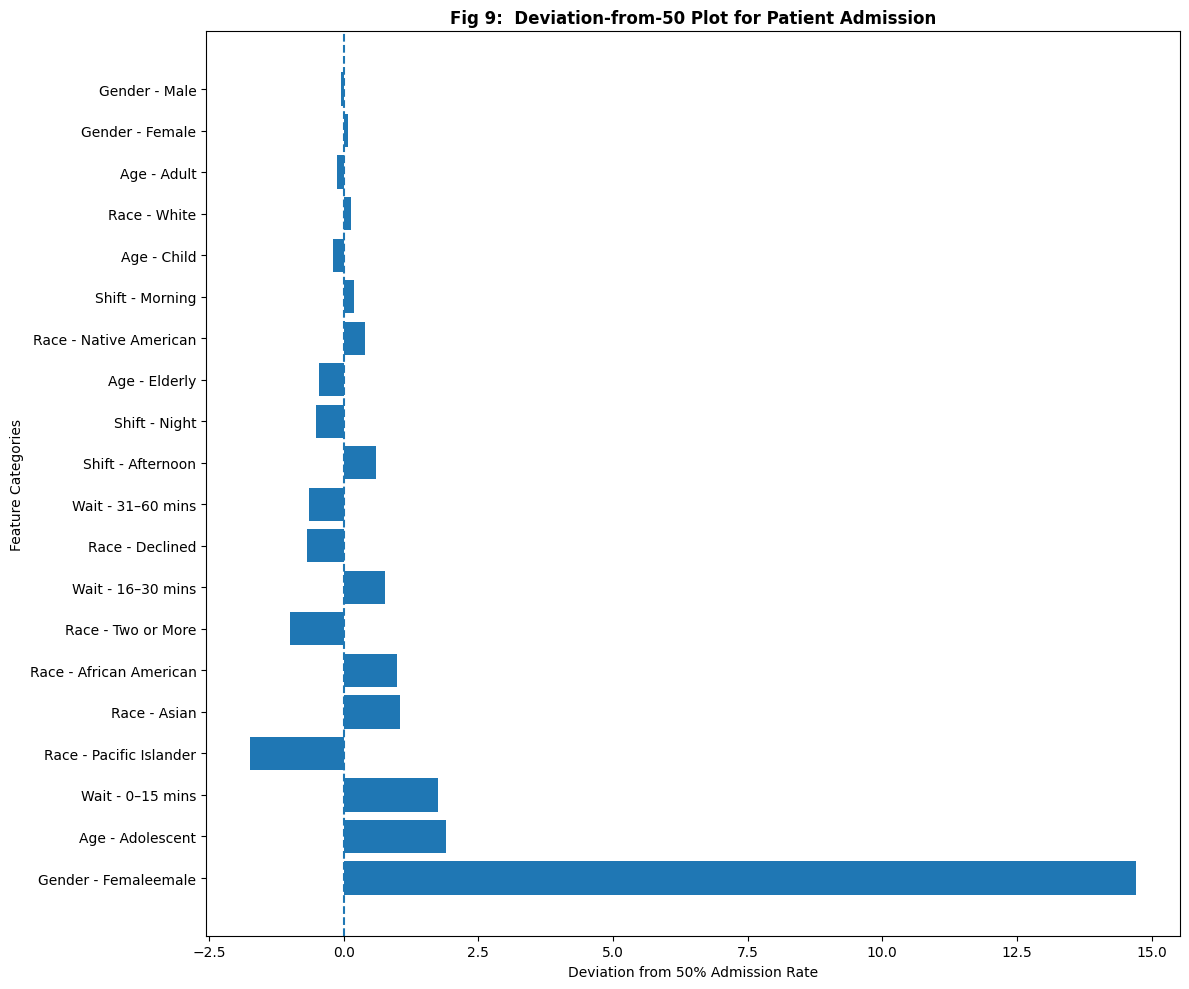

In [11]:
# Deviation from 50 Plot 

# ==========================================
# Create Data
# ==========================================

df = pd.DataFrame({

    "Category": [

        "Shift - Morning",
        "Shift - Afternoon",
        "Shift - Night",

        "Gender - Female",
        "Gender - Femaleemale",
        "Gender - Male",

        "Race - African American",
        "Race - Asian",
        "Race - Declined",
        "Race - Native American",
        "Race - Pacific Islander",
        "Race - Two or More",
        "Race - White",

        "Age - Child",
        "Age - Adolescent",
        "Age - Adult",
        "Age - Elderly",

        "Wait - 0–15 mins",
        "Wait - 16–30 mins",
        "Wait - 31–60 mins"
    ],

    "Admission Rate": [

        50.194049,
        50.609756,
        49.485714,

        50.089485,
        64.705882,
        49.947135,

        50.999487,
        51.037736,
        49.320388,
        50.401606,
        48.269581,
        49.004496,
        50.136134,

        49.810606,
        51.908397,
        49.871630,
        49.544863,

        51.756007,
        50.768654,
        49.350649
    ]
})

# ==========================================
# Calculate Deviation from 50%
# ==========================================

df["Deviation From 50"] = df["Admission Rate"] - 50

# ==========================================
# Sort by strongest deviation
# ==========================================

df = df.sort_values(
    by="Deviation From 50",
    key=abs,
    ascending=False
)

# ==========================================
# Plot
# ==========================================

plt.figure(figsize=(12, 10))

plt.barh(
    df["Category"],
    df["Deviation From 50"]
)

# Reference line at zero
plt.axvline(
    x=0,
    linestyle="--"
)

plt.xlabel("Deviation from 50% Admission Rate")
plt.ylabel("Feature Categories")

plt.title("Fig 9:  Deviation-from-50 Plot for Patient Admission", weight="bold")

plt.tight_layout()
plt.show()